In [7]:
from datasets import load_dataset

# Load the Oxford-IIIT Pet dataset
ds = load_dataset('timm/oxford-iiit-pet')

print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3680
    })
    test: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3669
    })
})


In [ ]:
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
training_args = TrainingArguments(
    output_dir="./vit_transformer2",
    per_device_train_batch_size=16,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0.001,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    learning_rate=1e-2,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([
    # transforms.RandomResizedCrop(resolution),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), 
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)), 
])

v.main(training_args, 'google/vit-base-patch16-384', augmentation)

Using device: cuda:0


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-384 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


KeyboardInterrupt: 

In [4]:
import numpy as np
import torch
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
import os

root = "./vit_transformer_224_test_learning_rate"
# l_min = np.log10(1e-04)
# l_max = np.log10(1e-02)
# number_of_lambdas = 10
# learning_rates = np.random.uniform(l_min, l_max, number_of_lambdas)
# learning_rates = 10 ** learning_rates
# learning_rates = np.append(learning_rates, [1e-4, 1e-2])
# print(learning_rates)
learning_rates = [1e-3]

training_args = TrainingArguments(
    # output_dir="./vit_transformer2",
    per_device_train_batch_size=8,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0.001,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    # learning_rate=1e-2,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([
    # transforms.RandomRotation(15),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomPerspective(distortion_scale=0.2, p=0.5), 
    # transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)), 
])


for l in learning_rates:
    training_args.learning_rate = l
    training_args.output_dir = os.path.join(root, f"{l:.03e}")
    print(f'Learning rate: {l:.03e}')
    v.main(training_args, 'google/vit-base-patch16-224', augmentation)
    print('')
    torch.cuda.empty_cache()

Learning rate: 1.000e-03


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,3.013400,2.850965,0.411685
200,1.164200,1.057312,0.820652
300,0.408500,0.430132,0.894022
400,0.218600,0.296948,0.915761
500,0.101000,0.233255,0.926630
600,0.140000,0.219878,0.926630
700,0.116500,0.180611,0.945652
800,0.103000,0.205385,0.930707
900,0.080100,0.195332,0.934783
1000,0.135600,0.217766,0.926630


***** train metrics *****
  epoch                    =      4.3478
  total_flos               = 924066285GF
  train_loss               =      0.4848
  train_runtime            =  0:02:19.55
  train_samples_per_second =      316.44
  train_steps_per_second   =      39.555


***** eval metrics *****
  epoch                   =     4.3478
  eval_accuracy           =      0.924
  eval_loss               =     0.2537
  eval_runtime            = 0:00:20.60
  eval_samples_per_second =    178.053
  eval_steps_per_second   =     22.275



In [5]:
import numpy as np
import torch
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
import os

root = "./vit_transformer_224_test_learning_rate_augmentation"
# l_min = np.log10(1e-04)
# l_max = np.log10(1e-02)
# number_of_lambdas = 10
# learning_rates = np.random.uniform(l_min, l_max, number_of_lambdas)
# learning_rates = 10 ** learning_rates
# learning_rates = np.append(learning_rates, [1e-4, 1e-2])
# print(learning_rates)
learning_rates = [1e-3]

training_args = TrainingArguments(
    # output_dir="./vit_transformer2",
    per_device_train_batch_size=8,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0.001,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    # learning_rate=1e-2,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), 
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)), 
])


for l in learning_rates:
    training_args.learning_rate = l
    training_args.output_dir = os.path.join(root, f"{l:.03e}")
    print(f'Learning rate: {l:.03e}')
    v.main(training_args, 'google/vit-base-patch16-224', augmentation)
    print('')
    torch.cuda.empty_cache()

Learning rate: 1.000e-03


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,2.833300,2.707947,0.456522
200,1.117100,0.988010,0.854620
300,0.373800,0.413564,0.903533
400,0.222700,0.297634,0.917120
500,0.094800,0.228641,0.932065
600,0.148700,0.215111,0.927989
700,0.106500,0.175587,0.945652
800,0.106100,0.198145,0.930707
900,0.081200,0.188344,0.937500
1000,0.121200,0.213731,0.929348


***** train metrics *****
  epoch                    =      4.3478
  total_flos               = 924066285GF
  train_loss               =      0.4735
  train_runtime            =  0:02:17.34
  train_samples_per_second =     321.527
  train_steps_per_second   =      40.191


***** eval metrics *****
  epoch                   =     4.3478
  eval_accuracy           =     0.9199
  eval_loss               =     0.2536
  eval_runtime            = 0:00:18.22
  eval_samples_per_second =    201.275
  eval_steps_per_second   =      25.18



In [6]:
import numpy as np
import torch
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
import os

root = "./vit_transformer_224_test_learning_rate_augmentation2"
# l_min = np.log10(1e-04)
# l_max = np.log10(1e-02)
# number_of_lambdas = 10
# learning_rates = np.random.uniform(l_min, l_max, number_of_lambdas)
# learning_rates = 10 ** learning_rates
# learning_rates = np.append(learning_rates, [1e-4, 1e-2])
# print(learning_rates)
learning_rates = [1e-3]

training_args = TrainingArguments(
    # output_dir="./vit_transformer2",
    per_device_train_batch_size=16,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0.001,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    # learning_rate=1e-2,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), 
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)), 
])


for l in learning_rates:
    training_args.learning_rate = l
    training_args.output_dir = os.path.join(root, f"{l:.03e}")
    print(f'Learning rate: {l:.03e}')
    v.main(training_args, 'google/vit-base-patch16-224', augmentation)
    print('')
    torch.cuda.empty_cache()

Learning rate: 1.000e-03


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,1.717000,1.487385,0.811141
200,0.331500,0.350254,0.918478
300,0.214800,0.231566,0.927989
400,0.161600,0.191954,0.936141
500,0.087300,0.196354,0.927989
600,0.089500,0.164102,0.947011
700,0.124400,0.176666,0.945652
800,0.045100,0.159194,0.948370
900,0.045000,0.172544,0.941576
1000,0.024500,0.176388,0.948370


Unfroze last 1 layers at epoch 5.0
Unfroze last 2 layers at epoch 7.0
***** train metrics *****
  epoch                    =       7.0652
  total_flos               = 1501607714GF
  train_loss               =       0.3478
  train_runtime            =   0:02:44.59
  train_samples_per_second =      268.302
  train_steps_per_second   =       16.769


***** eval metrics *****
  epoch                   =     7.0652
  eval_accuracy           =      0.924
  eval_loss               =     0.2487
  eval_runtime            = 0:00:18.73
  eval_samples_per_second =    195.797
  eval_steps_per_second   =     24.495



In [ ]:
import numpy as np
import torch
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
import os

root = "./vit_transformer_224_test_learning_rate_augmentation3"
# l_min = np.log10(1e-04)
# l_max = np.log10(1e-02)
# number_of_lambdas = 10
# learning_rates = np.random.uniform(l_min, l_max, number_of_lambdas)
# learning_rates = 10 ** learning_rates
# learning_rates = np.append(learning_rates, [1e-4, 1e-2])
# print(learning_rates)
learning_rates = [1e-3]

training_args = TrainingArguments(
    # output_dir="./vit_transformer2",
    per_device_train_batch_size=16,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0.001,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    # learning_rate=1e-2,
    # lr_scheduler_type="cosine",
    # warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([
    # transforms.RandomRotation(15),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomPerspective(distortion_scale=0.2, p=0.5), 
    # transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)), 
])


for l in learning_rates:
    training_args.learning_rate = l
    training_args.output_dir = os.path.join(root, f"{l:.03e}")
    print(f'Learning rate: {l:.03e}')
    v.main(training_args, 'google/vit-base-patch16-224', augmentation)
    print('')
    torch.cuda.empty_cache()

Learning rate: 1.000e-03


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,0.354500,0.323864,0.907609
200,0.150700,0.212129,0.930707
300,0.133900,0.202687,0.938859
400,0.109500,0.179943,0.937500
500,0.063000,0.184950,0.934783
600,0.071400,0.165687,0.951087
700,0.095500,0.174757,0.942935
800,0.041300,0.160997,0.952446
900,0.040600,0.169494,0.940217
1000,0.018200,0.169832,0.947011


Unfroze last 1 layers at epoch 5.0
Unfroze last 2 layers at epoch 7.0
***** train metrics *****
  epoch                    =       7.0652
  total_flos               = 1501607714GF
  train_loss               =       0.1405
  train_runtime            =   0:02:38.22
  train_samples_per_second =      279.103
  train_steps_per_second   =       17.444


***** eval metrics *****
  epoch                   =     7.0652
  eval_accuracy           =     0.9223
  eval_loss               =     0.2463
  eval_runtime            = 0:00:19.41
  eval_samples_per_second =    188.996
  eval_steps_per_second   =     23.644



# find learning rate

In [21]:
import numpy as np
l_min = np.log10(1e-05)
l_max = np.log10(1e-01)
number_of_lambdas = 8
log_lambdas = np.linspace(l_min, l_max, number_of_lambdas)
# log_lambdas = np.random.uniform(l_min, l_max, number_of_lambdas)
learning_rates = 10 ** log_lambdas
print(learning_rates)

[1.00000000e-05 3.72759372e-05 1.38949549e-04 5.17947468e-04
 1.93069773e-03 7.19685673e-03 2.68269580e-02 1.00000000e-01]


In [22]:
import numpy as np
import torch
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
import os

root = "./vit_transformer_224_test_learning_rate_augmentation4"
learning_rates = [1.00000000e-05, 3.72759372e-05, 1.38949549e-04, 5.17947468e-04]

training_args = TrainingArguments(
    # output_dir="./vit_transformer2",
    per_device_train_batch_size=16,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    # learning_rate=1e-2,
    # lr_scheduler_type="cosine",
    # warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([
    # transforms.RandomRotation(15),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomPerspective(distortion_scale=0.2, p=0.5), 
    # transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)), 
])

for l in learning_rates:
    training_args.learning_rate = l
    training_args.output_dir = os.path.join(root, f"{l:.03e}")
    print(f'Learning rate: {l:.03e}')
    v.main(training_args, 'google/vit-base-patch16-224', augmentation)
    print('')
    torch.cuda.empty_cache()

Learning rate: 1.000e-05


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,3.624700,3.649035,0.044837
200,3.574900,3.506319,0.082880
300,3.350700,3.372528,0.122283
400,3.268900,3.246513,0.176630
500,3.196700,3.127717,0.229620
600,3.046500,3.015728,0.320652
700,2.941900,2.910109,0.388587
800,2.798200,2.812176,0.449728
900,2.671000,2.722038,0.514946
1000,2.672300,2.627475,0.561141


Unfroze last 1 layers at epoch 5.0
Unfroze last 2 layers at epoch 7.0
Unfroze last 3 layers at epoch 9.0
Unfroze last 4 layers at epoch 11.0
Unfroze last 5 layers at epoch 13.0
***** train metrics *****
  epoch                    =         15.0
  total_flos               = 3188028686GF
  train_loss               =       2.4404
  train_runtime            =   0:06:38.22
  train_samples_per_second =      110.891
  train_steps_per_second   =        6.931


***** eval metrics *****
  epoch                   =       15.0
  eval_accuracy           =     0.7939
  eval_loss               =     1.8044
  eval_runtime            = 0:00:18.25
  eval_samples_per_second =    200.936
  eval_steps_per_second   =     25.138

Learning rate: 3.728e-05


...

***** eval metrics *****
  epoch                   =       15.0
  eval_accuracy           =     0.9338
  eval_loss               =     0.2083
  eval_runtime            = 0:00:19.03
  eval_samples_per_second =    192.749
  eval_steps_per_second   =     24.113

Learning rate: 5.179e-04


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,0.564000,0.494891,0.899457
200,0.252700,0.282506,0.932065
300,0.199700,0.237802,0.938859
400,0.182400,0.198782,0.945652
500,0.114300,0.196689,0.941576
600,0.120300,0.177523,0.951087
700,0.141100,0.181771,0.941576
800,0.084800,0.168142,0.952446
900,0.080900,0.175251,0.944293
1000,0.052400,0.168152,0.944293


Unfroze last 1 layers at epoch 5.0
Unfroze last 2 layers at epoch 7.0
Unfroze last 3 layers at epoch 9.0
Unfroze last 4 layers at epoch 11.0
Unfroze last 5 layers at epoch 13.0
***** train metrics *****
  epoch                    =         15.0
  total_flos               = 3188028686GF
  train_loss               =       0.1075
  train_runtime            =   0:05:59.61
  train_samples_per_second =      122.799
  train_steps_per_second   =        7.675


***** eval metrics *****
  epoch                   =       15.0
  eval_accuracy           =     0.9349
  eval_loss               =     0.2471
  eval_runtime            = 0:00:17.77
  eval_samples_per_second =    206.393
  eval_steps_per_second   =      25.82



In [23]:
import numpy as np
import torch
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
import os

root = "./vit_transformer_224_test_learning_rate_augmentation4"
learning_rates = [1.93069773e-03, 7.19685673e-03, 2.68269580e-02, 1.00000000e-01]

training_args = TrainingArguments(
    # output_dir="./vit_transformer2",
    per_device_train_batch_size=16,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    # learning_rate=1e-2,
    # lr_scheduler_type="cosine",
    # warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([
    # transforms.RandomRotation(15),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomPerspective(distortion_scale=0.2, p=0.5), 
    # transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)), 
])

for l in learning_rates:
    training_args.learning_rate = l
    training_args.output_dir = os.path.join(root, f"{l:.03e}")
    print(f'Learning rate: {l:.03e}')
    v.main(training_args, 'google/vit-base-patch16-224', augmentation)
    print('')
    torch.cuda.empty_cache()

Learning rate: 1.931e-03


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,0.314500,0.322188,0.884511
200,0.103100,0.205497,0.930707
300,0.109700,0.229023,0.927989
400,0.084000,0.185423,0.947011
500,0.041100,0.177648,0.936141
600,0.053100,0.187751,0.944293
700,0.056300,0.188245,0.937500
800,0.012900,0.174491,0.942935
900,0.013500,0.180120,0.940217
1000,0.010900,0.201574,0.941576


Unfroze last 1 layers at epoch 5.0
Unfroze last 2 layers at epoch 7.0
***** train metrics *****
  epoch                    =       7.0652
  total_flos               = 1501607714GF
  train_loss               =       0.1043
  train_runtime            =   0:02:37.92
  train_samples_per_second =       279.62
  train_steps_per_second   =       17.476


***** eval metrics *****
  epoch                   =     7.0652
  eval_accuracy           =      0.925
  eval_loss               =     0.2594
  eval_runtime            = 0:00:18.02
  eval_samples_per_second =    203.549
  eval_steps_per_second   =     25.464

Learning rate: 7.197e-03


...

***** eval metrics *****
  epoch                   =     4.8913
  eval_accuracy           =     0.8735
  eval_loss               =      2.523
  eval_runtime            = 0:00:18.59
  eval_samples_per_second =    197.356
  eval_steps_per_second   =      24.69

Learning rate: 1.000e-01


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,8.325800,6.774350,0.845109
200,3.173900,5.119234,0.898098
300,5.485500,6.502975,0.899457
400,2.146500,7.937485,0.873641
500,0.866800,6.657308,0.908967
600,2.995300,7.246099,0.908967
700,1.134400,7.672937,0.903533


***** train metrics *****
  epoch                    =      3.8043
  total_flos               = 808558000GF
  train_loss               =      4.0164
  train_runtime            =  0:01:23.92
  train_samples_per_second =      526.21
  train_steps_per_second   =      32.888


***** eval metrics *****
  epoch                   =     3.8043
  eval_accuracy           =      0.882
  eval_loss               =     7.0954
  eval_runtime            = 0:00:19.21
  eval_samples_per_second =    190.915
  eval_steps_per_second   =     23.884



# find learning rate 

Using device: cuda:0
Learning rate: 1.000e-02


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,0.644400,0.680615,0.855978
200,0.264200,0.583967,0.895380
300,0.138100,0.581288,0.896739
400,0.179500,0.660854,0.915761
500,0.199000,0.604403,0.913043
600,0.205200,0.596839,0.925272
700,0.091500,0.716919,0.914402
800,0.115400,0.617319,0.926630
900,0.096900,0.615634,0.918478
1000,0.027200,0.553855,0.921196


***** train metrics *****
  epoch                    =         15.0
  total_flos               = 3188028686GF
  train_loss               =       0.1004
  train_runtime            =   0:05:22.13
  train_samples_per_second =      137.085
  train_steps_per_second   =        8.568


***** eval metrics *****
  epoch                   =       15.0
  eval_accuracy           =     0.9128
  eval_loss               =     0.8565
  eval_runtime            = 0:00:18.94
  eval_samples_per_second =    193.632
  eval_steps_per_second   =     24.224
plot_log start
[{'loss': 2.713, 'grad_norm': 3.8848819732666016, 'learning_rate': 0.009967391304347826, 'epoch': 0.05434782608695652, 'step': 10}, {'loss': 1.0252, 'grad_norm': 4.333650588989258, 'learning_rate': 0.009931159420289855, 'epoch': 0.10869565217391304, 'step': 20}, {'loss': 0.7524, 'grad_norm': 3.493166446685791, 'learning_rate': 0.009894927536231885, 'epoch': 0.16304347826086957, 'step': 30}, {'loss': 0.7465, 'grad_norm': 3.186148166656494, 'learning_rate': 0.009858695652173913, 'epoch': 0.21739130434782608, 'step': 40}, {'loss': 0.6597, 'grad_norm': 2.124145984649658, 'learning_rate': 0.009822463768115942, 'epoch': 0.2717391304347826, 'step': 50}, {'loss': 0.5897, 'grad_norm': 2.3990612030029297, 'learning_rate': 0.00

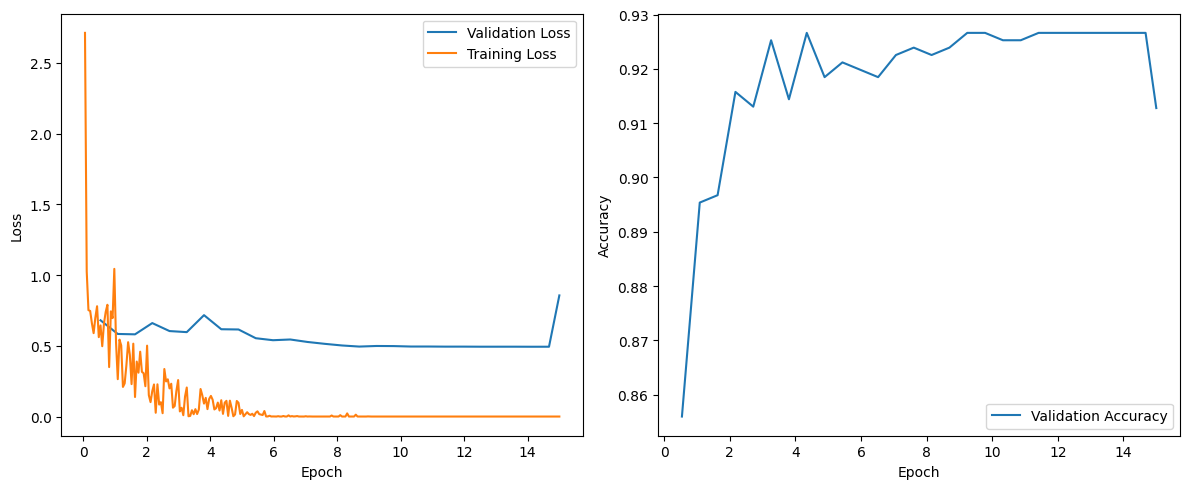

plot_log end
Learning rate: 1.000e-02
-----------------------


In [1]:
# Learning Rates for Non-Differential Training
import numpy as np
import torch
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
import os

root = "./vit_transformer_224_test_learning_rate_augmentation4"
learning_rates = [1e-2]

training_args = TrainingArguments(
    # output_dir="./vit_transformer2",
    per_device_train_batch_size=16,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    learning_rate=1e-2,
    # lr_scheduler_type="cosine",
    # warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([])
    # trainer = Trainer(
    #     model=model,
    #     args=training_args,
    #     data_collator=collate_fn,
    #     compute_metrics=compute_metrics,
    #     train_dataset=train_set,
    #     eval_dataset=val_set,
    #     processing_class=processor,
    # )
for l in learning_rates:
    training_args.learning_rate = l
    training_args.output_dir = os.path.join(root, f"{l:.03e}")
    print(f'Learning rate: {l:.03e}')
    v.main(training_args, 'google/vit-base-patch16-224', augmentation)
    print(f'Learning rate: {l:.03e}')
    torch.cuda.empty_cache()
    print('-----------------------')


In [ ]:
# Table Learning Rates for Differential Training
import numpy as np
import torch
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
import os

root = "./vit_transformer_224_test_learning_rate_augmentation6"
learning_rates = [2e-3, 1e-3, 5e-4, 1e-4, 5e-5]

training_args = TrainingArguments(
    # output_dir="./vit_transformer2",
    per_device_train_batch_size=16,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    learning_rate=1e-2,
    # lr_scheduler_type="cosine",
    # warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([])

for l in learning_rates:
    training_args.learning_rate = l
    training_args.output_dir = os.path.join(root, f"{l:.03e}")
    print(f'Learning rate: {l:.03e}')
    v.main(training_args, 'google/vit-base-patch16-224', augmentation)
    print(f'Learning rate: {l:.03e}')
    torch.cuda.empty_cache()
    print('-----------------------')

Learning rate: 2.000e-03


KeyboardInterrupt: 

Using device: cuda:0
Learning rate: 1.000e-02


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,0.382000,0.370508,0.866848
200,0.105500,0.301755,0.922554
300,0.442900,0.605010,0.872283
400,0.381200,0.631236,0.888587
500,0.283600,0.559820,0.910326
600,0.074000,0.666595,0.904891
700,0.563000,0.779817,0.910326


***** train metrics *****
  epoch                    =      3.8043
  total_flos               = 808558000GF
  train_loss               =      0.4557
  train_runtime            =  0:01:26.93
  train_samples_per_second =      507.95
  train_steps_per_second   =      31.747


***** eval metrics *****
  epoch                   =     3.8043
  eval_accuracy           =     0.8828
  eval_loss               =     0.4594
  eval_runtime            = 0:00:18.30
  eval_samples_per_second =    200.453
  eval_steps_per_second   =     25.077
plot_log start
[{'loss': 3.6516, 'grad_norm': 6.868325233459473, 'learning_rate': 0.0003260869565217391, 'epoch': 0.05434782608695652, 'step': 10}, {'loss': 3.1524, 'grad_norm': 6.4862542152404785, 'learning_rate': 0.0006884057971014493, 'epoch': 0.10869565217391304, 'step': 20}, {'loss': 2.2706, 'grad_norm': 5.164093494415283, 'learning_rate': 0.0010507246376811595, 'epoch': 0.16304347826086957, 'step': 30}, {'loss': 1.3582, 'grad_norm': 4.05984354019165, 'learning_rate': 0.0014130434782608694, 'epoch': 0.21739130434782608, 'step': 40}, {'loss': 0.7871, 'grad_norm': 3.706676959991455, 'learning_rate': 0.0017753623188405798, 'epoch': 0.2717391304347826, 'step': 50}, {'loss': 0.4547, 'grad_norm': 0.793353259563446, 'learning_rate': 

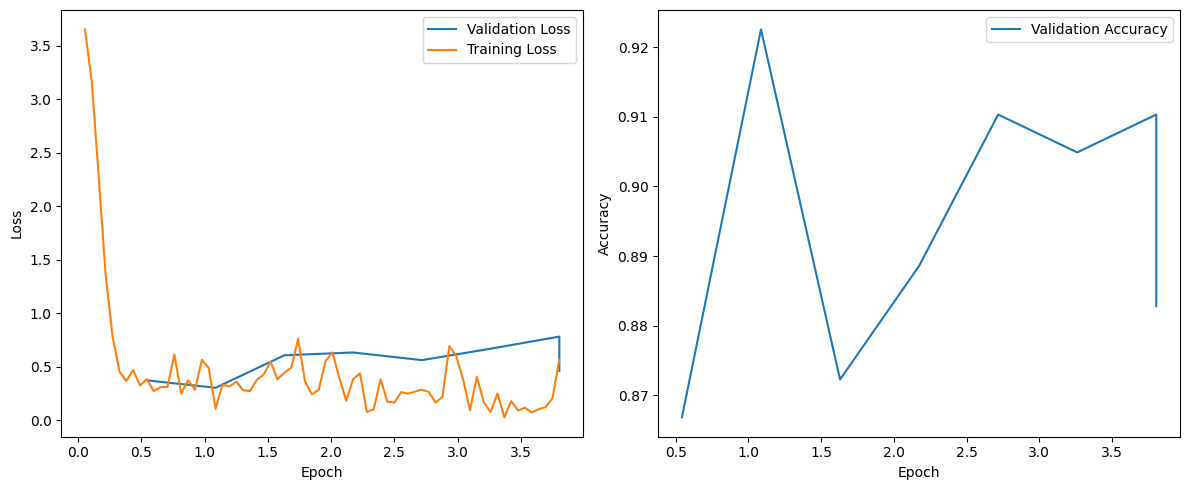

plot_log end
Learning rate: 1.000e-02
-----------------------
Learning rate: 1.000e-03


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,1.778900,1.580777,0.782609
200,0.342800,0.365439,0.917120
300,0.229500,0.244549,0.923913
400,0.161100,0.202069,0.932065
500,0.085500,0.201523,0.933424
600,0.083300,0.172212,0.947011
700,0.138000,0.186487,0.941576
800,0.048600,0.167087,0.947011
900,0.046700,0.178708,0.937500
1000,0.023500,0.179162,0.947011


Unfroze last 1 layers at epoch 5.0
Unfroze last 2 layers at epoch 7.0
***** train metrics *****
  epoch                    =       7.0652
  total_flos               = 1501607714GF
  train_loss               =       0.3588
  train_runtime            =   0:02:40.66
  train_samples_per_second =      274.851
  train_steps_per_second   =       17.178


KeyboardInterrupt: 

In [1]:
import numpy as np
import torch
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
import os

root = "./vit_transformer_224_test_learning_rate_augmentation5"
learning_rates = [1e-2, 1e-3]

training_args = TrainingArguments(
    # output_dir="./vit_transformer2",
    per_device_train_batch_size=16,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    learning_rate=1e-2,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([])

for l in learning_rates:
    training_args.learning_rate = l
    training_args.output_dir = os.path.join(root, f"{l:.03e}")
    print(f'Learning rate: {l:.03e}')
    v.main(training_args, 'google/vit-base-patch16-224', augmentation)
    print(f'Learning rate: {l:.03e}')
    torch.cuda.empty_cache()
    print('-----------------------')

Using device: cuda:0
Learning rate: 1.000e-02


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,0.370100,0.377506,0.869565
200,0.097300,0.318110,0.915761
300,0.451000,0.725496,0.864130
400,0.264100,0.780763,0.875000
500,0.285500,0.657509,0.908967
600,0.484100,0.725411,0.902174
700,0.396900,0.833364,0.892663


***** train metrics *****
  epoch                    =      3.8043
  total_flos               = 808558000GF
  train_loss               =      0.4679
  train_runtime            =  0:01:27.56
  train_samples_per_second =     504.302
  train_steps_per_second   =      31.519


***** eval metrics *****
  epoch                   =     3.8043
  eval_accuracy           =     0.8883
  eval_loss               =     0.4545
  eval_runtime            = 0:00:18.42
  eval_samples_per_second =    199.169
  eval_steps_per_second   =     24.916
plot_log start
[{'loss': 3.6428, 'grad_norm': 6.86777400970459, 'learning_rate': 0.0003260869565217391, 'epoch': 0.05434782608695652, 'step': 10}, {'loss': 3.1783, 'grad_norm': 6.475091934204102, 'learning_rate': 0.0006884057971014493, 'epoch': 0.10869565217391304, 'step': 20}, {'loss': 2.2902, 'grad_norm': 5.280386924743652, 'learning_rate': 0.0010507246376811595, 'epoch': 0.16304347826086957, 'step': 30}, {'loss': 1.3311, 'grad_norm': 4.176910877227783, 'learning_rate': 0.0014130434782608694, 'epoch': 0.21739130434782608, 'step': 40}, {'loss': 0.7794, 'grad_norm': 3.6937716007232666, 'learning_rate': 0.0017753623188405798, 'epoch': 0.2717391304347826, 'step': 50}, {'loss': 0.4355, 'grad_norm': 1.095557689666748, 'learning_rate': 

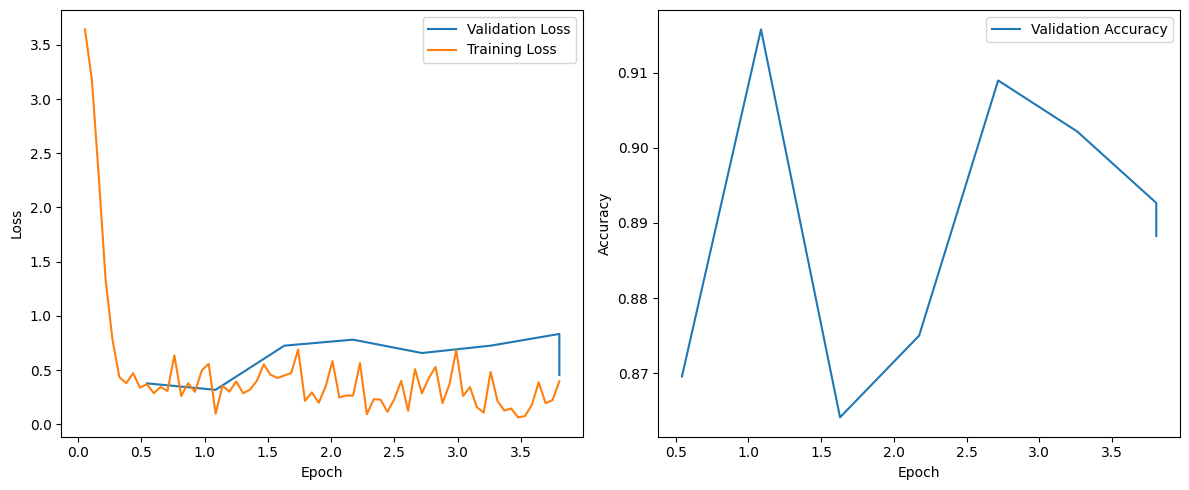

plot_log end
Learning rate: 1.000e-02
-----------------------
Learning rate: 1.000e-03


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,1.778900,1.580777,0.782609
200,0.342800,0.365439,0.917120
300,0.229500,0.244549,0.923913
400,0.161100,0.202069,0.932065
500,0.085500,0.201523,0.933424
600,0.083300,0.172212,0.947011
700,0.138000,0.186487,0.941576
800,0.048600,0.167087,0.947011
900,0.046700,0.178708,0.937500
1000,0.023500,0.179162,0.947011


Unfroze last 1 layers at epoch 5.0
Unfroze last 2 layers at epoch 7.0
***** train metrics *****
  epoch                    =       7.0652
  total_flos               = 1501607714GF
  train_loss               =       0.3588
  train_runtime            =   0:02:36.90
  train_samples_per_second =      281.439
  train_steps_per_second   =        17.59


***** eval metrics *****
  epoch                   =     7.0652
  eval_accuracy           =     0.9248
  eval_loss               =     0.2495
  eval_runtime            = 0:00:18.01
  eval_samples_per_second =    203.644
  eval_steps_per_second   =     25.476
plot_log start
[{'loss': 3.752, 'grad_norm': 6.934295654296875, 'learning_rate': 3.260869565217391e-05, 'epoch': 0.05434782608695652, 'step': 10}, {'loss': 3.7412, 'grad_norm': 6.894463539123535, 'learning_rate': 6.884057971014493e-05, 'epoch': 0.10869565217391304, 'step': 20}, {'loss': 3.6824, 'grad_norm': 6.446513652801514, 'learning_rate': 0.00010507246376811594, 'epoch': 0.16304347826086957, 'step': 30}, {'loss': 3.5479, 'grad_norm': 6.4067702293396, 'learning_rate': 0.00014130434782608694, 'epoch': 0.21739130434782608, 'step': 40}, {'loss': 3.3283, 'grad_norm': 6.556089401245117, 'learning_rate': 0.000177536231884058, 'epoch': 0.2717391304347826, 'step': 50}, {'loss': 2.9855, 'grad_norm': 6.035599231719971, 'learning_rate': 0.

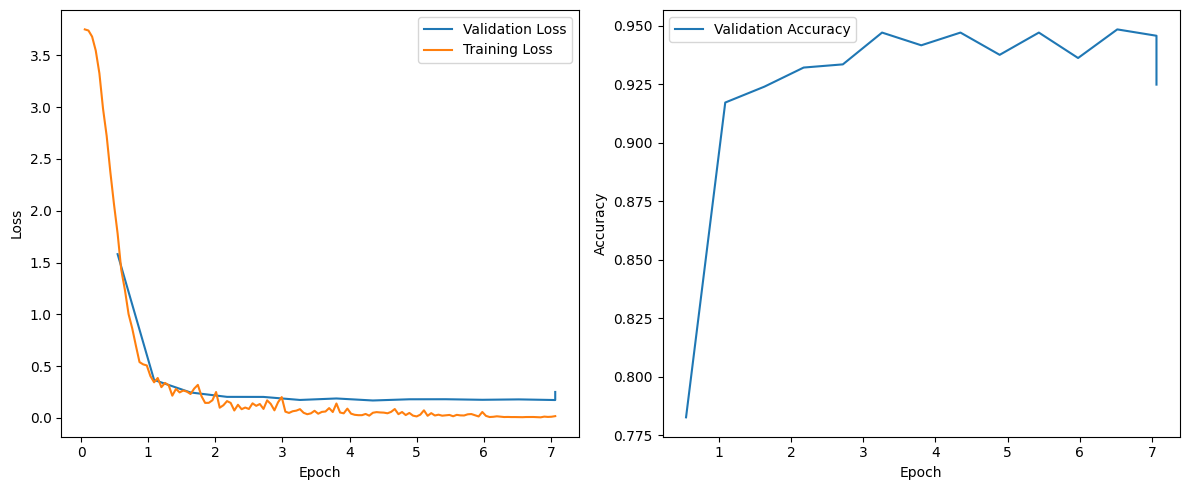

plot_log end
Learning rate: 1.000e-03
-----------------------
Learning rate: 5.000e-04


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,2.581400,2.394517,0.627717
200,0.718000,0.682504,0.898098
300,0.327300,0.327914,0.927989
400,0.261500,0.232328,0.937500
500,0.145100,0.219013,0.932065
600,0.139200,0.184692,0.944293
700,0.170900,0.188322,0.933424
800,0.094400,0.169181,0.942935
900,0.088000,0.176363,0.934783
1000,0.054300,0.166312,0.940217


Unfroze last 1 layers at epoch 5.0
Unfroze last 2 layers at epoch 7.0
Unfroze last 3 layers at epoch 9.0
Unfroze last 4 layers at epoch 11.0
Unfroze last 5 layers at epoch 13.0
***** train metrics *****
  epoch                    =      14.6739
  total_flos               = 3118723714GF
  train_loss               =       0.2334
  train_runtime            =   0:05:54.42
  train_samples_per_second =      124.596
  train_steps_per_second   =        7.787


***** eval metrics *****
  epoch                   =    14.6739
  eval_accuracy           =     0.9302
  eval_loss               =     0.2478
  eval_runtime            = 0:00:17.95
  eval_samples_per_second =    204.371
  eval_steps_per_second   =     25.567
plot_log start
[{'loss': 3.7024, 'grad_norm': 6.89044713973999, 'learning_rate': 1.6304347826086955e-05, 'epoch': 0.05434782608695652, 'step': 10}, {'loss': 3.5949, 'grad_norm': 6.86827278137207, 'learning_rate': 3.4420289855072465e-05, 'epoch': 0.10869565217391304, 'step': 20}, {'loss': 3.5874, 'grad_norm': 6.51502799987793, 'learning_rate': 5.253623188405797e-05, 'epoch': 0.16304347826086957, 'step': 30}, {'loss': 3.5001, 'grad_norm': 6.394576072692871, 'learning_rate': 7.065217391304347e-05, 'epoch': 0.21739130434782608, 'step': 40}, {'loss': 3.3956, 'grad_norm': 6.637198448181152, 'learning_rate': 8.8768115942029e-05, 'epoch': 0.2717391304347826, 'step': 50}, {'loss': 3.3221, 'grad_norm': 6.27379035949707, 'learning_rate': 0.00

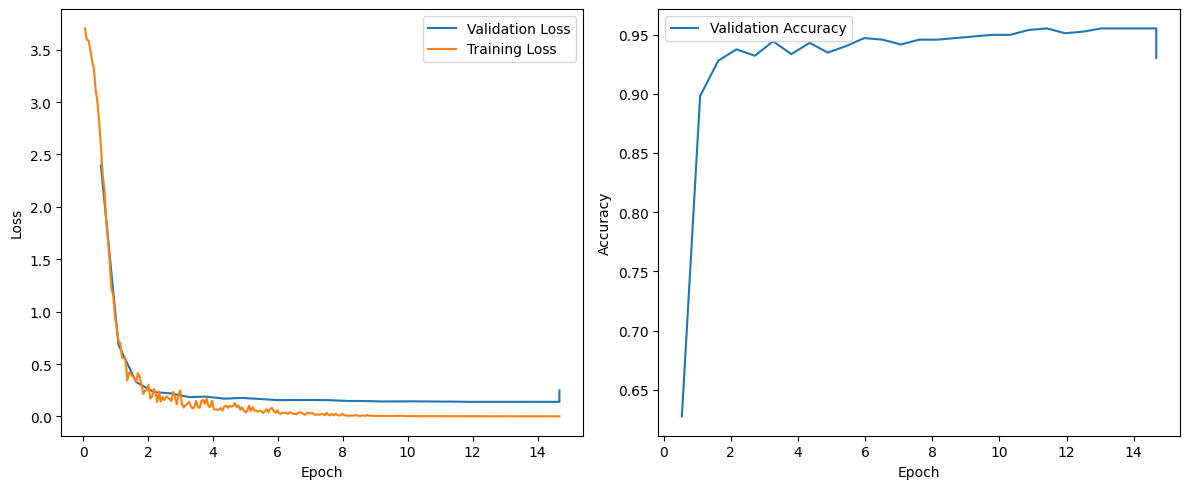

plot_log end
Learning rate: 5.000e-04
-----------------------
Learning rate: 1.000e-04


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,3.490200,3.432179,0.066576
200,2.775600,2.694527,0.512228
300,1.714400,1.721676,0.762228
400,1.062000,1.051028,0.853261
500,0.735600,0.725659,0.889946
600,0.563200,0.558221,0.907609
700,0.491200,0.459279,0.923913
800,0.388100,0.391251,0.932065
900,0.338100,0.356330,0.932065
1000,0.335800,0.310482,0.937500


Unfroze last 1 layers at epoch 5.0
Unfroze last 2 layers at epoch 7.0
Unfroze last 3 layers at epoch 9.0
Unfroze last 4 layers at epoch 11.0
Unfroze last 5 layers at epoch 13.0
***** train metrics *****
  epoch                    =         15.0
  total_flos               = 3188028686GF
  train_loss               =       0.5644
  train_runtime            =   0:06:04.75
  train_samples_per_second =      121.066
  train_steps_per_second   =        7.567


***** eval metrics *****
  epoch                   =       15.0
  eval_accuracy           =     0.9335
  eval_loss               =     0.2176
  eval_runtime            = 0:00:18.40
  eval_samples_per_second =    199.371
  eval_steps_per_second   =     24.942
plot_log start
[{'loss': 3.6174, 'grad_norm': 6.868592739105225, 'learning_rate': 3.2608695652173914e-06, 'epoch': 0.05434782608695652, 'step': 10}, {'loss': 3.6391, 'grad_norm': 6.89461088180542, 'learning_rate': 6.884057971014493e-06, 'epoch': 0.10869565217391304, 'step': 20}, {'loss': 3.6599, 'grad_norm': 6.486917018890381, 'learning_rate': 1.0507246376811594e-05, 'epoch': 0.16304347826086957, 'step': 30}, {'loss': 3.6354, 'grad_norm': 6.486509799957275, 'learning_rate': 1.4130434782608694e-05, 'epoch': 0.21739130434782608, 'step': 40}, {'loss': 3.609, 'grad_norm': 6.720343112945557, 'learning_rate': 1.7753623188405798e-05, 'epoch': 0.2717391304347826, 'step': 50}, {'loss': 3.6606, 'grad_norm': 6.403858661651611, 'learning_rate'

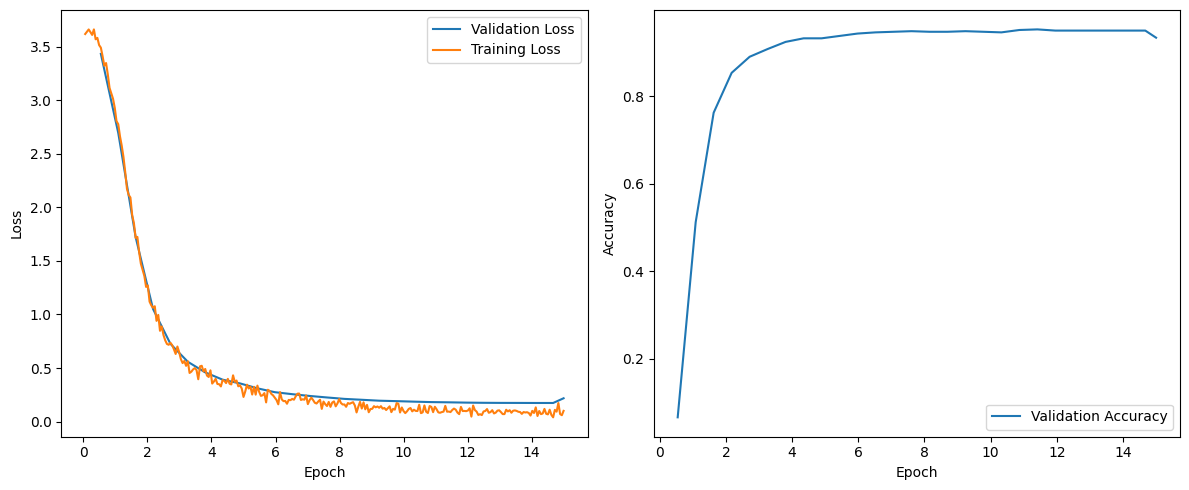

plot_log end
Learning rate: 1.000e-04
-----------------------
Learning rate: 5.000e-05


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
100,3.609700,3.564198,0.027174
200,3.228200,3.176381,0.165761
300,2.600200,2.593648,0.570652
400,2.013100,2.025208,0.743207
500,1.583100,1.569802,0.805707
600,1.259400,1.230513,0.835598
700,1.018800,0.990702,0.861413
800,0.815900,0.822952,0.879076
900,0.719500,0.713950,0.899457
1000,0.655000,0.608089,0.906250


Unfroze last 1 layers at epoch 5.0
Unfroze last 2 layers at epoch 7.0
Unfroze last 3 layers at epoch 9.0
Unfroze last 4 layers at epoch 11.0
Unfroze last 5 layers at epoch 13.0
***** train metrics *****
  epoch                    =         15.0
  total_flos               = 3188028686GF
  train_loss               =       0.8637
  train_runtime            =   0:06:06.52
  train_samples_per_second =      120.484
  train_steps_per_second   =         7.53


***** eval metrics *****
  epoch                   =       15.0
  eval_accuracy           =     0.9272
  eval_loss               =     0.2933
  eval_runtime            = 0:00:17.83
  eval_samples_per_second =    205.732
  eval_steps_per_second   =     25.738
plot_log start
[{'loss': 3.6177, 'grad_norm': 6.868666648864746, 'learning_rate': 1.6304347826086957e-06, 'epoch': 0.05434782608695652, 'step': 10}, {'loss': 3.642, 'grad_norm': 6.896607398986816, 'learning_rate': 3.4420289855072464e-06, 'epoch': 0.10869565217391304, 'step': 20}, {'loss': 3.6678, 'grad_norm': 6.489114761352539, 'learning_rate': 5.253623188405797e-06, 'epoch': 0.16304347826086957, 'step': 30}, {'loss': 3.6515, 'grad_norm': 6.49042272567749, 'learning_rate': 7.065217391304347e-06, 'epoch': 0.21739130434782608, 'step': 40}, {'loss': 3.6346, 'grad_norm': 6.728234767913818, 'learning_rate': 8.876811594202899e-06, 'epoch': 0.2717391304347826, 'step': 50}, {'loss': 3.6999, 'grad_norm': 6.414677143096924, 'learning_rate': 

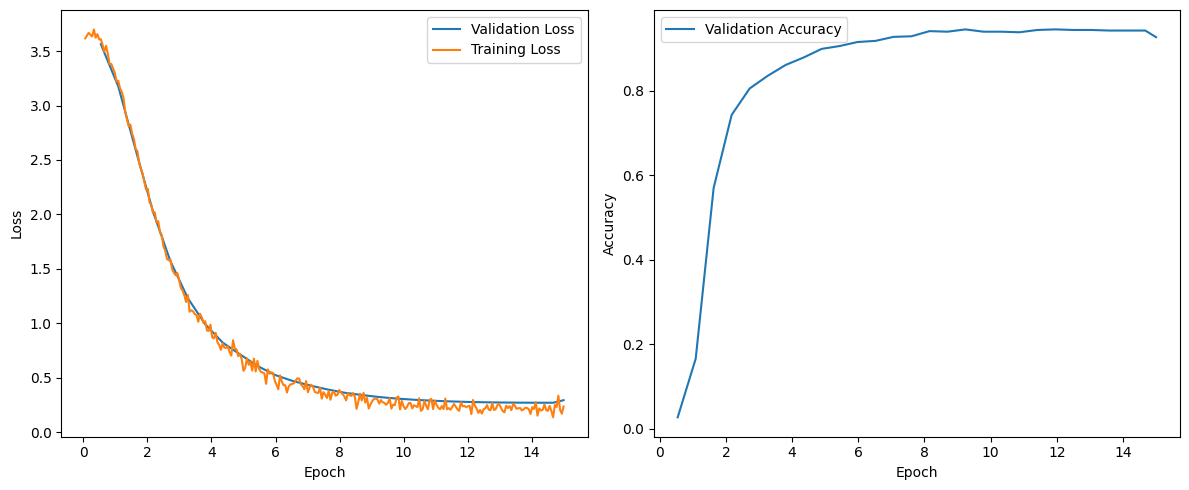

plot_log end
Learning rate: 5.000e-05
-----------------------


In [1]:
# Table Learning Rates for augmentation
import numpy as np
import torch
import VitTransformer as v
from transformers import TrainingArguments
from torchvision import transforms
import os

root = "./vit_transformer_224_test_learning_rate_augmentation7"
learning_rates = [1e-2, 1e-3, 5e-4, 1e-4, 5e-5]

training_args = TrainingArguments(
    # output_dir="./vit_transformer2",
    per_device_train_batch_size=16,
    eval_strategy="steps",
    num_train_epochs=15,
    fp16=True,
    save_steps=100,
    eval_steps=100,
    logging_steps=10,
    save_total_limit=2,
    weight_decay=0,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    # learning rate
    # learning_rate=1e-2,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,  
)  

augmentation = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), 
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)), 
])

for l in learning_rates:
    training_args.learning_rate = l
    training_args.output_dir = os.path.join(root, f"{l:.03e}")
    print(f'Learning rate: {l:.03e}')
    v.main(training_args, 'google/vit-base-patch16-224', augmentation)
    print(f'Learning rate: {l:.03e}')
    torch.cuda.empty_cache()
    print('-----------------------')